# Formula 1 Lap Time Predictor

**Track:** Classical Machine Learning / Regression  
**Race:** 2019 British Grand Prix  
**Models:** Linear Regression and Random Forest Regression

This notebook predicts Formula 1 lap times and investigates whether tire age improves prediction compared with a baseline using grid position and lap number.


In [3]:
!git clone https://github.com/TanviBhambhani/F1-Lap-Time-Predictor-
%cd F1-Lap-Time-Predictor

Cloning into 'F1-Lap-Time-Predictor-'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 28 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 5.70 MiB | 3.79 MiB/s, done.
Resolving deltas: 100% (6/6), done.
[Errno 2] No such file or directory: 'F1-Lap-Time-Predictor'
/content


In [4]:
%cd F1-Lap-Time-Predictor-

/content/F1-Lap-Time-Predictor-


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")


Libraries imported successfully.


In [6]:
lap_times = pd.read_csv("data/lap_times.csv")
pit_stops = pd.read_csv("data/pit_stops.csv")
results = pd.read_csv("data/results.csv")
races = pd.read_csv("data/races.csv")

print("lap_times:", lap_times.shape)
print("pit_stops:", pit_stops.shape)
print("results:", results.shape)
print("races:", races.shape)


lap_times: (589081, 6)
pit_stops: (11371, 7)
results: (26759, 18)
races: (1125, 18)


## 1. Race Selection

The selected race is the **2019 British Grand Prix**. Drivers who completed at least 90% of the winner's race distance are considered, and eight qualifying drivers are selected.

In [7]:
RACE_YEAR = 2019
RACE_NAME = "British Grand Prix"

race_info = races[(races["year"] == RACE_YEAR) & (races["name"] == RACE_NAME)].copy()

if race_info.empty:
    raise ValueError("Selected race was not found in races.csv")

race_id = race_info.iloc[0]["raceId"]

print("Selected race:", RACE_NAME)
print("Year:", RACE_YEAR)
print("Race ID:", race_id)
print("Date:", race_info.iloc[0]["date"])


Selected race: British Grand Prix
Year: 2019
Race ID: 1019
Date: 2019-07-14


In [8]:
race_results = results[results["raceId"] == race_id].copy()

winner_laps = race_results["laps"].max()
completed_results = race_results[race_results["laps"] >= 0.90 * winner_laps].copy()
completed_results = completed_results.sort_values("positionOrder")

print("Winner's laps:", winner_laps)
display(completed_results[["driverId", "grid", "positionOrder", "laps"]].head(10))


Winner's laps: 52


,driverId,grid,positionOrder,laps
24380,1,2,1,52
24381,822,1,2,52
24382,844,3,3,52
24383,842,5,4,52
24384,830,4,5,52
24385,832,13,6,52
24386,817,7,7,52
24387,8,12,8,52
24388,826,17,9,52
24389,807,10,10,52


In [9]:
selected_drivers = completed_results.head(8)["driverId"].astype(int).tolist()

print("Selected driver IDs:")
print(selected_drivers)


Selected driver IDs:
[1, 822, 844, 842, 830, 832, 817, 8]


## 2. Data Cleaning

The assignment requires removal of pit-stop laps, the lap immediately after a pit stop, and laps slower than 1.5 times the driver's median lap time.

In [10]:
race_laps = lap_times[
    (lap_times["raceId"] == race_id) &
    (lap_times["driverId"].isin(selected_drivers))
].copy()

race_laps["lap_time_seconds"] = race_laps["milliseconds"] / 1000
race_laps = race_laps.sort_values(["driverId", "lap"]).reset_index(drop=True)

print("Raw selected lap records:", len(race_laps))
display(race_laps.head())


Raw selected lap records: 416


,raceId,driverId,lap,position,time,milliseconds,lap_time_seconds
0,1019,1,1,2,1:34.895,94895,94.895
1,1019,1,2,2,1:31.923,91923,91.923
2,1019,1,3,2,1:31.635,91635,91.635
3,1019,1,4,2,1:32.058,92058,92.058
4,1019,1,5,2,1:31.540,91540,91.540


In [11]:
race_pits = pit_stops[
    (pit_stops["raceId"] == race_id) &
    (pit_stops["driverId"].isin(selected_drivers))
].copy()

pit_laps = set(zip(
    race_pits["driverId"].astype(int),
    race_pits["lap"].astype(int)
))

print("Number of pit stops:", len(pit_laps))
print(sorted(pit_laps))


Number of pit stops: 12
[(1, 20), (8, 17), (817, 12), (817, 20), (822, 16), (822, 45), (830, 13), (830, 20), (832, 20), (842, 12), (844, 13), (844, 21)]


In [12]:
race_laps["driver_lap"] = list(zip(
    race_laps["driverId"].astype(int),
    race_laps["lap"].astype(int)
))

pit_lap_mask = race_laps["driver_lap"].isin(pit_laps)
post_pit_laps = {(driver_id, lap + 1) for driver_id, lap in pit_laps}
post_pit_mask = race_laps["driver_lap"].isin(post_pit_laps)

before = len(race_laps)
race_laps = race_laps[~(pit_lap_mask | post_pit_mask)].copy()
removed_pit_laps = before - len(race_laps)

print("Pit-related laps removed:", removed_pit_laps)


Pit-related laps removed: 24


In [13]:
driver_medians = (
    race_laps.groupby("driverId")["lap_time_seconds"]
    .median()
    .rename("driver_median")
)

race_laps = race_laps.merge(driver_medians, on="driverId", how="left")

slow_lap_mask = race_laps["lap_time_seconds"] > 1.5 * race_laps["driver_median"]
slow_laps_removed = int(slow_lap_mask.sum())

race_laps = race_laps[~slow_lap_mask].copy()

print("Slow/outlier laps removed:", slow_laps_removed)
print("Total removed:", removed_pit_laps + slow_laps_removed)
print("Remaining observations:", len(race_laps))


Slow/outlier laps removed: 9
Total removed: 33
Remaining observations: 383


## 3. Feature Engineering: Tire Age

`tire_age` represents laps elapsed since the most recent pit stop and resets at the beginning of a new stint.

In [14]:
original_race_laps = lap_times[
    (lap_times["raceId"] == race_id) &
    (lap_times["driverId"].isin(selected_drivers))
].copy()

original_race_laps = original_race_laps.sort_values(["driverId", "lap"]).reset_index(drop=True)
original_race_laps["last_pit_lap"] = 0

for driver_id in selected_drivers:
    driver_pits = sorted(
        race_pits.loc[race_pits["driverId"] == driver_id, "lap"].astype(int).tolist()
    )
    mask = original_race_laps["driverId"] == driver_id

    for idx in original_race_laps[mask].index:
        current_lap = int(original_race_laps.loc[idx, "lap"])
        previous_pits = [p for p in driver_pits if p < current_lap]
        if previous_pits:
            original_race_laps.loc[idx, "last_pit_lap"] = max(previous_pits)

# First lap of the race = 0; first lap after a pit stop = 0.
original_race_laps["tire_age"] = (
    original_race_laps["lap"] - original_race_laps["last_pit_lap"] - 1
).clip(lower=0)

race_laps = race_laps.drop(columns=["driver_lap"], errors="ignore")
race_laps = race_laps.merge(
    original_race_laps[["driverId", "lap", "tire_age"]],
    on=["driverId", "lap"],
    how="left"
)

display(race_laps[["driverId", "lap", "lap_time_seconds", "tire_age"]].head(15))


,driverId,lap,lap_time_seconds,tire_age
0,1,1,94.895,0
1,1,2,91.923,1
2,1,3,91.635,2
3,1,4,92.058,3
4,1,5,91.540,4
5,1,6,90.967,5
6,1,7,90.940,6
7,1,8,90.850,7
8,1,9,91.140,8
9,1,10,90.972,9


In [15]:
grid_positions = race_results[["driverId", "grid"]].drop_duplicates("driverId")

race_laps = race_laps.merge(grid_positions, on="driverId", how="left")
race_laps = race_laps.dropna(subset=["lap_time_seconds", "tire_age", "grid"]).copy()

race_laps["grid"] = race_laps["grid"].astype(float)
race_laps["lap"] = race_laps["lap"].astype(float)
race_laps["tire_age"] = race_laps["tire_age"].astype(float)

print("Final cleaned observations:", len(race_laps))


Final cleaned observations: 383


## 4. Stint-Based Train/Test Split

A random split is deliberately avoided. For every selected driver, earlier stints are training data and the driver's final stint is test data.

In [16]:
race_laps["stint"] = 1

for driver_id in selected_drivers:
    driver_pits = sorted(
        race_pits.loc[race_pits["driverId"] == driver_id, "lap"].astype(int).tolist()
    )
    mask = race_laps["driverId"] == driver_id

    for pit_number, pit_lap in enumerate(driver_pits, start=1):
        race_laps.loc[
            mask & (race_laps["lap"] > pit_lap),
            "stint"
        ] = pit_number + 1

display(race_laps[["driverId", "lap", "stint", "tire_age"]].head(20))


,driverId,lap,stint,tire_age
0,1,1.0,1,0.0
1,1,2.0,1,1.0
2,1,3.0,1,2.0
3,1,4.0,1,3.0
4,1,5.0,1,4.0
5,1,6.0,1,5.0
6,1,7.0,1,6.0
7,1,8.0,1,7.0
8,1,9.0,1,8.0
9,1,10.0,1,9.0


In [17]:
train_parts, test_parts = [], []

for driver_id in selected_drivers:
    driver_data = race_laps[race_laps["driverId"] == driver_id].sort_values("lap")

    if driver_data["stint"].nunique() < 2:
        print(f"Driver {driver_id} skipped: only one stint available.")
        continue

    final_stint = driver_data["stint"].max()
    train_parts.append(driver_data[driver_data["stint"] < final_stint].copy())
    test_parts.append(driver_data[driver_data["stint"] == final_stint].copy())

if not train_parts or not test_parts:
    raise ValueError("Not enough multi-stint drivers for the required split.")

train_data = pd.concat(train_parts, ignore_index=True)
test_data = pd.concat(test_parts, ignore_index=True)

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))


Training observations: 156
Testing observations: 227


## 5. Model Training

Two algorithms are compared: Linear Regression and Random Forest Regression. Each is trained once with baseline features and once with the tire-age feature.

In [20]:
TARGET = "lap_time_seconds"

BASELINE_FEATURES = ["grid", "lap"]
ENHANCED_FEATURES = ["grid", "lap", "tire_age"]

X_train_baseline = train_data[BASELINE_FEATURES]
X_test_baseline = test_data[BASELINE_FEATURES]
X_train_enhanced = train_data[ENHANCED_FEATURES]
X_test_enhanced = test_data[ENHANCED_FEATURES]

y_train = train_data[TARGET]
y_test = test_data[TARGET]


In [21]:
linear_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_enhanced = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

rf_baseline = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=3, random_state=42
)

rf_enhanced = RandomForestRegressor(
    n_estimators=300, max_depth=10, min_samples_leaf=3, random_state=42
)


In [22]:
linear_baseline.fit(X_train_baseline, y_train)
linear_enhanced.fit(X_train_enhanced, y_train)

linear_baseline_pred = linear_baseline.predict(X_test_baseline)
linear_enhanced_pred = linear_enhanced.predict(X_test_enhanced)


In [23]:
rf_baseline.fit(X_train_baseline, y_train)
rf_enhanced.fit(X_train_enhanced, y_train)

rf_baseline_pred = rf_baseline.predict(X_test_baseline)
rf_enhanced_pred = rf_enhanced.predict(X_test_enhanced)


In [24]:
def calculate_metrics(actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    return rmse, mae

models = {
    "Linear Regression - Baseline": linear_baseline_pred,
    "Linear Regression - Tire Age": linear_enhanced_pred,
    "Random Forest - Baseline": rf_baseline_pred,
    "Random Forest - Tire Age": rf_enhanced_pred
}

rows = []
for name, pred in models.items():
    rmse, mae = calculate_metrics(y_test, pred)
    rows.append({"Model": name, "RMSE (seconds)": rmse, "MAE (seconds)": mae})

comparison_df = pd.DataFrame(rows).sort_values("RMSE (seconds)").reset_index(drop=True)
display(comparison_df)


,Model,RMSE (seconds),MAE (seconds)
0,Random Forest - Baseline,6.564095,2.160948
1,Random Forest - Tire Age,6.585038,2.387444
2,Linear Regression - Tire Age,6.916216,2.565363
3,Linear Regression - Baseline,7.173637,2.048634


In [25]:
linear_base_rmse = comparison_df.loc[
    comparison_df["Model"] == "Linear Regression - Baseline", "RMSE (seconds)"
].iloc[0]
linear_tire_rmse = comparison_df.loc[
    comparison_df["Model"] == "Linear Regression - Tire Age", "RMSE (seconds)"
].iloc[0]
rf_base_rmse = comparison_df.loc[
    comparison_df["Model"] == "Random Forest - Baseline", "RMSE (seconds)"
].iloc[0]
rf_tire_rmse = comparison_df.loc[
    comparison_df["Model"] == "Random Forest - Tire Age", "RMSE (seconds)"
].iloc[0]

print(f"Linear Regression RMSE improvement: {(linear_base_rmse-linear_tire_rmse)/linear_base_rmse*100:.2f}%")
print(f"Random Forest RMSE improvement: {(rf_base_rmse-rf_tire_rmse)/rf_base_rmse*100:.2f}%")

best_model_name = comparison_df.iloc[0]["Model"]
print("Best performing model:", best_model_name)


Linear Regression RMSE improvement: 3.59%
Random Forest RMSE improvement: -0.32%
Best performing model: Random Forest - Baseline


## 6. Predicted vs Actual Visualization

The plot below compares predicted and actual lap times for one driver's complete final test stint.

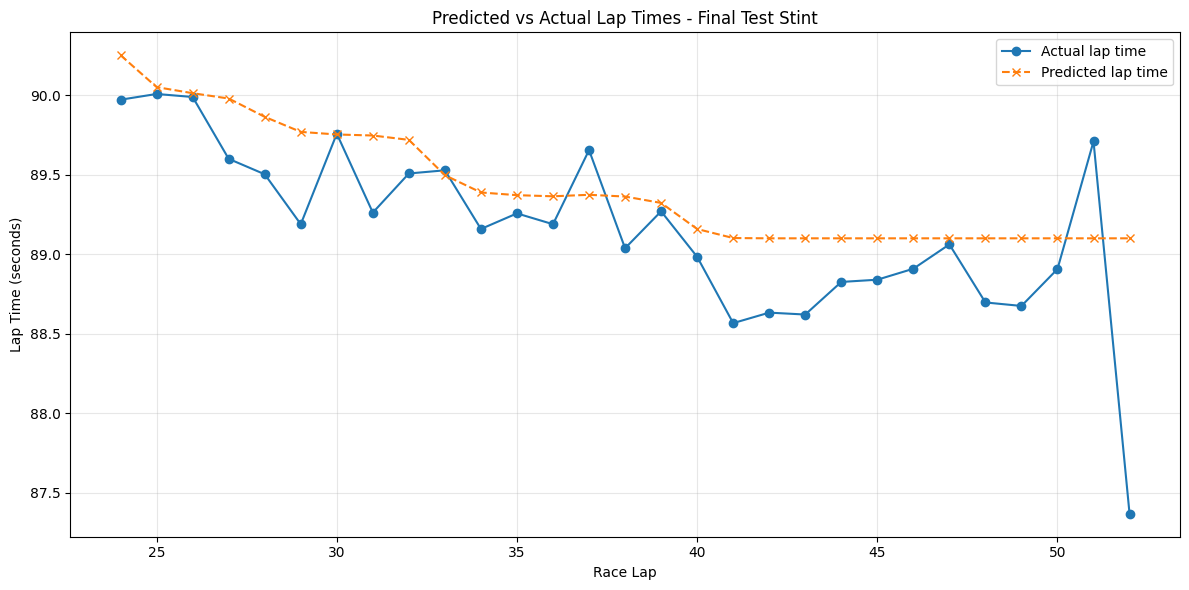

In [27]:
plot_driver = test_data["driverId"].iloc[0]
plot_data = test_data[test_data["driverId"] == plot_driver].sort_values("lap").copy()

if best_model_name == "Linear Regression - Baseline":
    plot_data["prediction"] = linear_baseline.predict(plot_data[BASELINE_FEATURES])
elif best_model_name == "Linear Regression - Tire Age":
    plot_data["prediction"] = linear_enhanced.predict(plot_data[ENHANCED_FEATURES])
elif best_model_name == "Random Forest - Baseline":
    plot_data["prediction"] = rf_baseline.predict(plot_data[BASELINE_FEATURES])
else:
    plot_data["prediction"] = rf_enhanced.predict(plot_data[ENHANCED_FEATURES])

plt.figure(figsize=(12, 6))
plt.plot(plot_data["lap"], plot_data["lap_time_seconds"], marker="o", label="Actual lap time")
plt.plot(plot_data["lap"], plot_data["prediction"], marker="x", linestyle="--", label="Predicted lap time")
plt.xlabel("Race Lap")
plt.ylabel("Lap Time (seconds)")
plt.title("Predicted vs Actual Lap Times - Final Test Stint")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig("images/predicted_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()


In [28]:
print("============================================")
print("FINAL PROJECT SUMMARY")
print("============================================")
print(f"Race: {RACE_NAME} {RACE_YEAR}")
print(f"Drivers selected: {len(selected_drivers)}")
print(f"Removed pit-related laps: {removed_pit_laps}")
print(f"Removed slow/outlier laps: {slow_laps_removed}")
print(f"Training observations: {len(train_data)}")
print(f"Testing observations: {len(test_data)}")
print(f"Best model: {best_model_name}")
display(comparison_df)


FINAL PROJECT SUMMARY
Race: British Grand Prix 2019
Drivers selected: 8
Removed pit-related laps: 24
Removed slow/outlier laps: 9
Training observations: 156
Testing observations: 227
Best model: Random Forest - Baseline


,Model,RMSE (seconds),MAE (seconds)
0,Random Forest - Baseline,6.564095,2.160948
1,Random Forest - Tire Age,6.585038,2.387444
2,Linear Regression - Tire Age,6.916216,2.565363
3,Linear Regression - Baseline,7.173637,2.048634
